## Predicción de Fuga de Clientes en Telecomunicaciones

El operador de telecomunicaciones **Interconnect** enfrenta un desafío crítico común en la industria: 
la **fuga de clientes (churn)**. La retención de clientes es fundamental para la rentabilidad a largo 
plazo, ya que:

- Adquirir un nuevo cliente cuesta entre 5-25 veces más que retener uno existente
- Los clientes leales generan mayor valor de vida útil (Customer Lifetime Value)
- La tasa de churn impacta directamente en los ingresos recurrentes

**Objetivo del Proyecto**: Desarrollar un modelo predictivo que identifique con anticipación qué 
clientes tienen mayor probabilidad de cancelar sus servicios, permitiendo al equipo de marketing 
implementar estrategias de retención proactivas (códigos promocionales, planes especiales, etc.).

## Descripción de los Datos

### **Fuente de Datos**

El dataset proviene de [Kaggle: Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) 
y contiene información histórica de clientes de Interconnect.

Para este análisis, trabajaremos con el dataset consolidado: 
`WA_Fn-UseC_-Telco-Customer-Churn.csv`

### **Variables Principales:**

**Información Demográfica:**
- `customerID`: Identificador único
- `gender`: Género del cliente
- `SeniorCitizen`: Si es adulto mayor (0/1)
- `Partner`: Si tiene pareja
- `Dependents`: Si tiene dependientes

**Servicios Contratados:**
- `PhoneService`, `MultipleLines`
- `InternetService` (DSL, Fiber optic, No)
- `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`
- `TechSupport`, `StreamingTV`, `StreamingMovies`

**Información del Contrato:**
- `tenure`: Meses como cliente
- `Contract`: Tipo de contrato
- `PaperlessBilling`: Facturación electrónica
- `PaymentMethod`: Método de pago
- `MonthlyCharges`: Cargo mensual
- `TotalCharges`: Cargo total acumulado

**Target Variable:**
- `Churn`: Si el cliente canceló el servicio (Yes/No)


## Table of Contents

[Aquí irían los links a cada sección del notebook]

---

## Import Libraries

In [1]:
import kagglehub
import pandas as pd
import os
import missingno as msno
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate


/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading & Initial Exploration

In [2]:

# Descargar el dataset (esto descarga todos los archivos)
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print(f"Dataset descargado en: {path}")

# Listar archivos descargados
files = os.listdir(path)
print(f"Archivos disponibles: {files}")

# Leer el archivo CSV específico
csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(csv_file)

Dataset descargado en: /home/ubuntu/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1
Archivos disponibles: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The target that we will use to guide the exploration is Churn

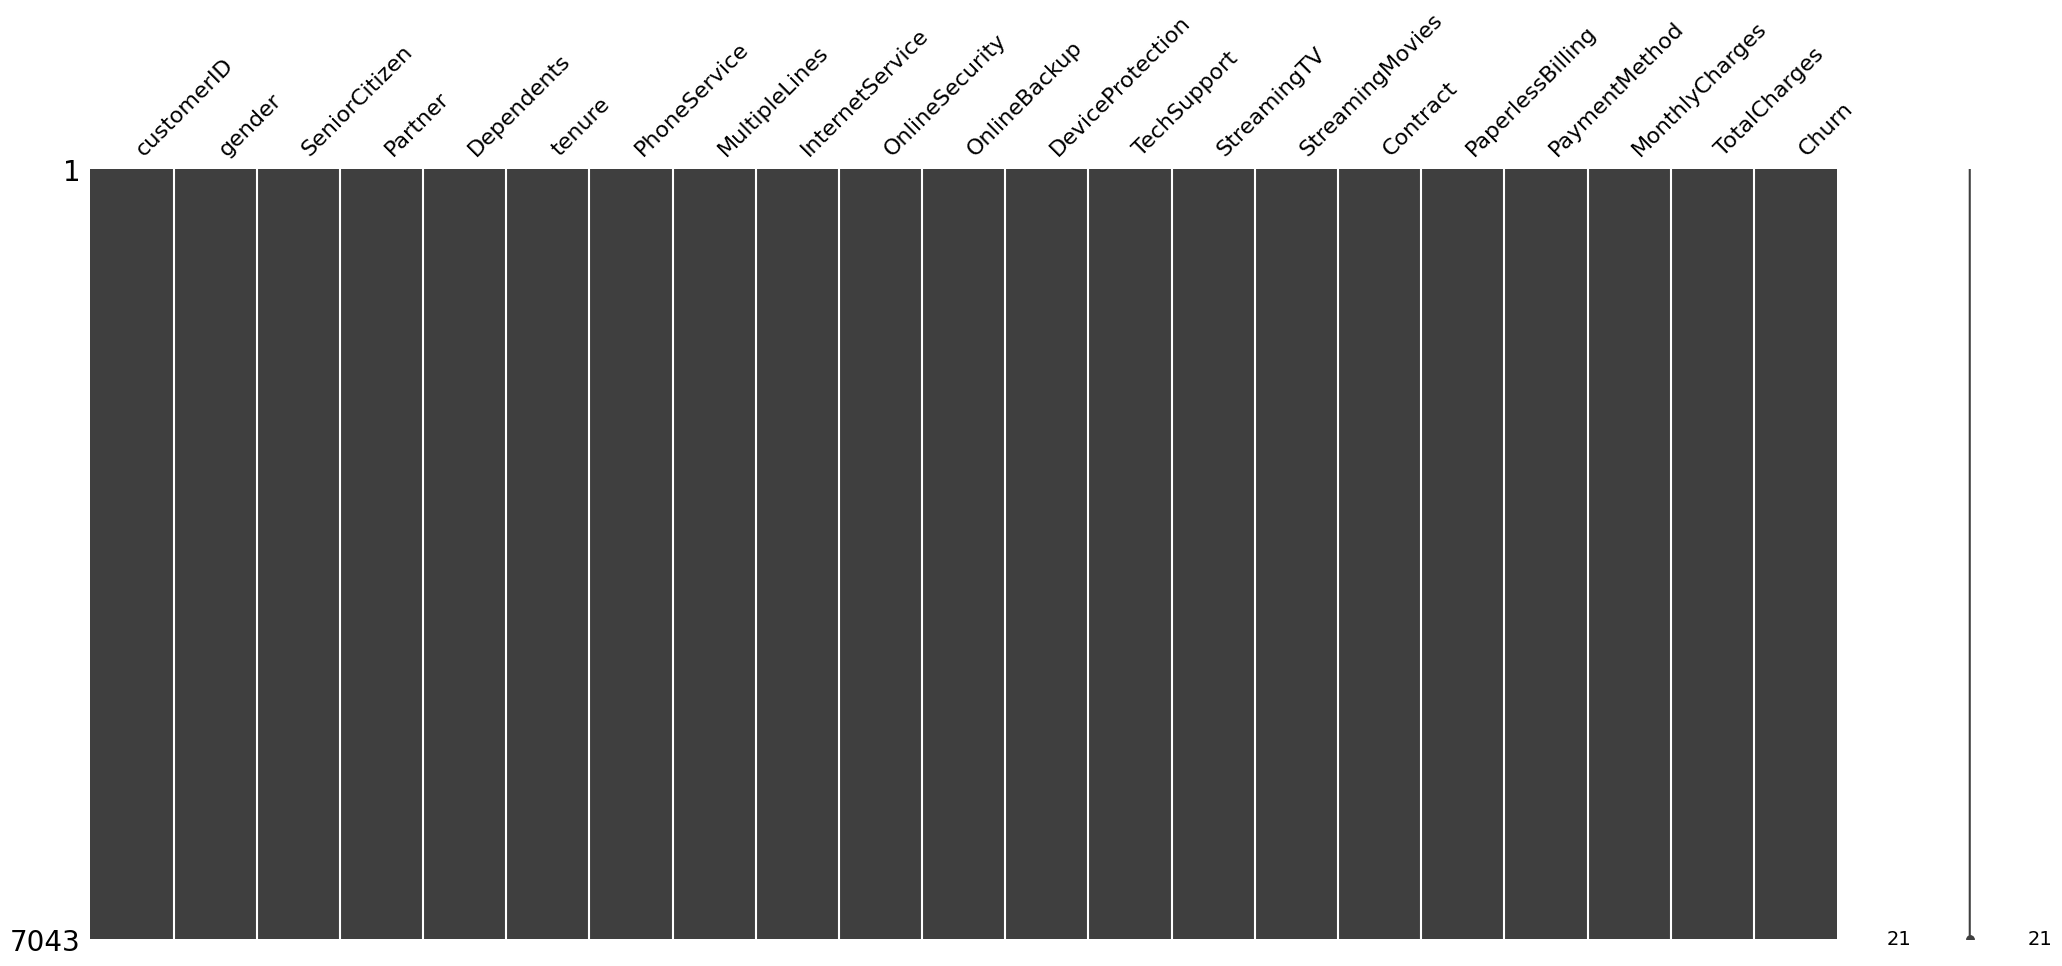

In [6]:
# Visualize missing values as a matrix
msno.matrix(df);

<Axes: >

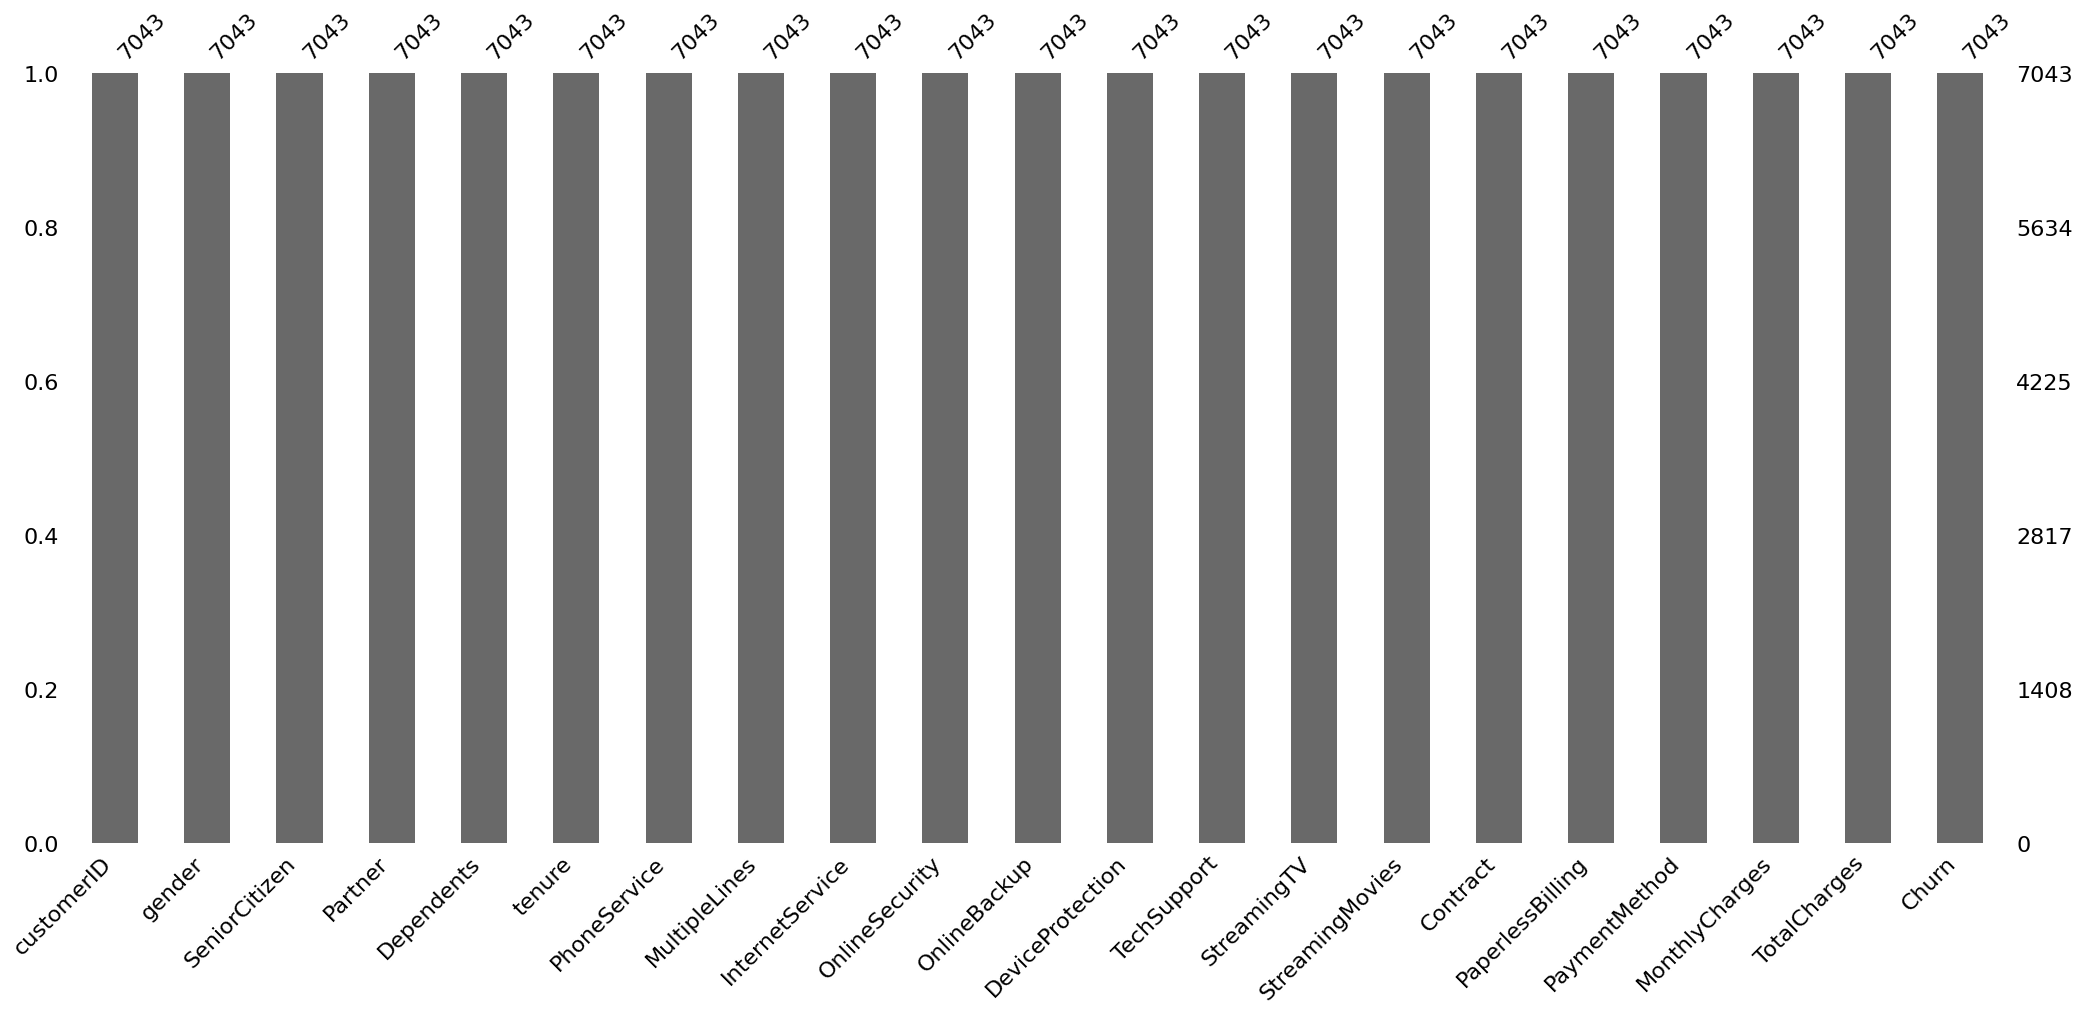

In [7]:
msno.bar(df)

The dataset does not show any missing values initially, which is positive for the analysis. However, we will check later if there are any inconsistent values that require treatment.

In [8]:
df.duplicated().sum()

np.int64(0)

There is also no duplicated values in the dataset.

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning

Antes de proceder con el análisis, es fundamental asegurar la calidad de los datos. 
En esta sección abordaremos:
- Eliminación de variables innecesarias
- Estandarización de nombres de columnas
- Corrección de tipos de datos
- Tratamiento de valores faltantes ocultos

Primero eliminamos la variable customerID, que no es relevante para el análisis.

In [10]:
df.drop(['customerID'], axis = 1, inplace = True)

### 3.1 Standardize Column Names

Creamos una función para cambiar los nombres de las columnas a snake_case.

In [11]:
# Crear función para cambiar nombres de columnas
def to_snake_case(name):
    name = name.replace(' ', '_')
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

# Renombrar columnas usando la función to_snake_case
df.columns = [to_snake_case(col) for col in df.columns]
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

Ahora convertamos la columna total_charges a tipo numeric, que es la única columna con un tipo de dato incorrecto.

### 3.2 Fix Data Types

In [ ]:
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

gender                0
senior_citizen        0
partner               0
dependents            0
tenure                0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
contract              0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
churn                 0
dtype: int64

### 3.3 Investigate Missing Values

In [ ]:
df.isnull().sum()

Here we see that the TotalCharges has 11 missing values. Let's check this data.

In [13]:
df[df['total_charges'].isnull()]

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Let's delete the rows with missing values in "total_charges" columns since there are only 11 rows and deleting them will not affect the data.

In [14]:
df = df[df['total_charges'].notna()]

Verificamos que no hayan valores faltantes en el dataset.

In [15]:
df.isnull().sum()

gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

### 3.4 Convert Binary Encoding

In [16]:
df["senior_citizen"]= df["senior_citizen"].map({0: "No", 1: "Yes"})
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Conclusion

Tras el proceso de limpieza, el dataset está listo para el análisis. Eliminamos la columna customerID por no aportar valor predictivo, estandarizamos los nombres a formato snake_case, y corregimos el tipo de dato de total_charges. Identificamos 11 registros con valores faltantes (clientes de 1 mes sin cargos registrados) que representan menos del 0.2% del dataset y fueron eliminados para evitar ruido. Finalmente, convertimos senior_citizen a formato categórico para mantener consistencia. El dataset final no presenta valores faltantes, duplicados, ni inconsistencias.

### 3.5 Final Data Quality Check

In [ ]:
print(f"Final dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

## Exploratory Data Analysis (EDA)

### 4.1 Target Variable Analysis

Lets verify the distribution of the target variable.

/tmp/ipykernel_793582/2134367287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='churn', palette='Set2')


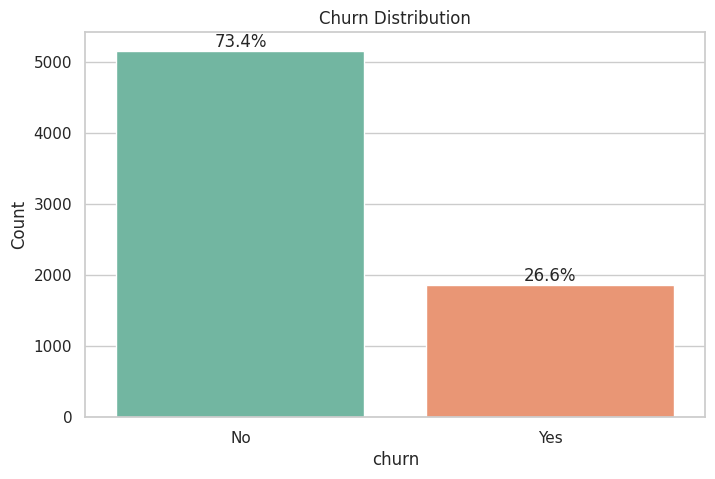

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='churn', palette='Set2')

total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title('Churn Distribution')
plt.ylabel('Count')
plt.show()


- 26.6% of the customers switched to another provider.

### 4.2 Numerical Variables

In [19]:
numeric_columns = ["tenure", "monthly_charges", "total_charges"]
target_column = ['churn']
categorical_columns = list(set(df.columns) - set(numeric_columns) - set(target_column))
categorical_columns

['online_backup',
 'paperless_billing',
 'streaming_tv',
 'streaming_movies',
 'phone_service',
 'contract',
 'gender',
 'tech_support',
 'payment_method',
 'online_security',
 'internet_service',
 'device_protection',
 'partner',
 'multiple_lines',
 'senior_citizen',
 'dependents']

tenure: mean=32.42 | median=29.00 | skew=0.24
monthly_charges: mean=64.80 | median=70.35 | skew=-0.22
total_charges: mean=2283.30 | median=1397.47 | skew=0.96


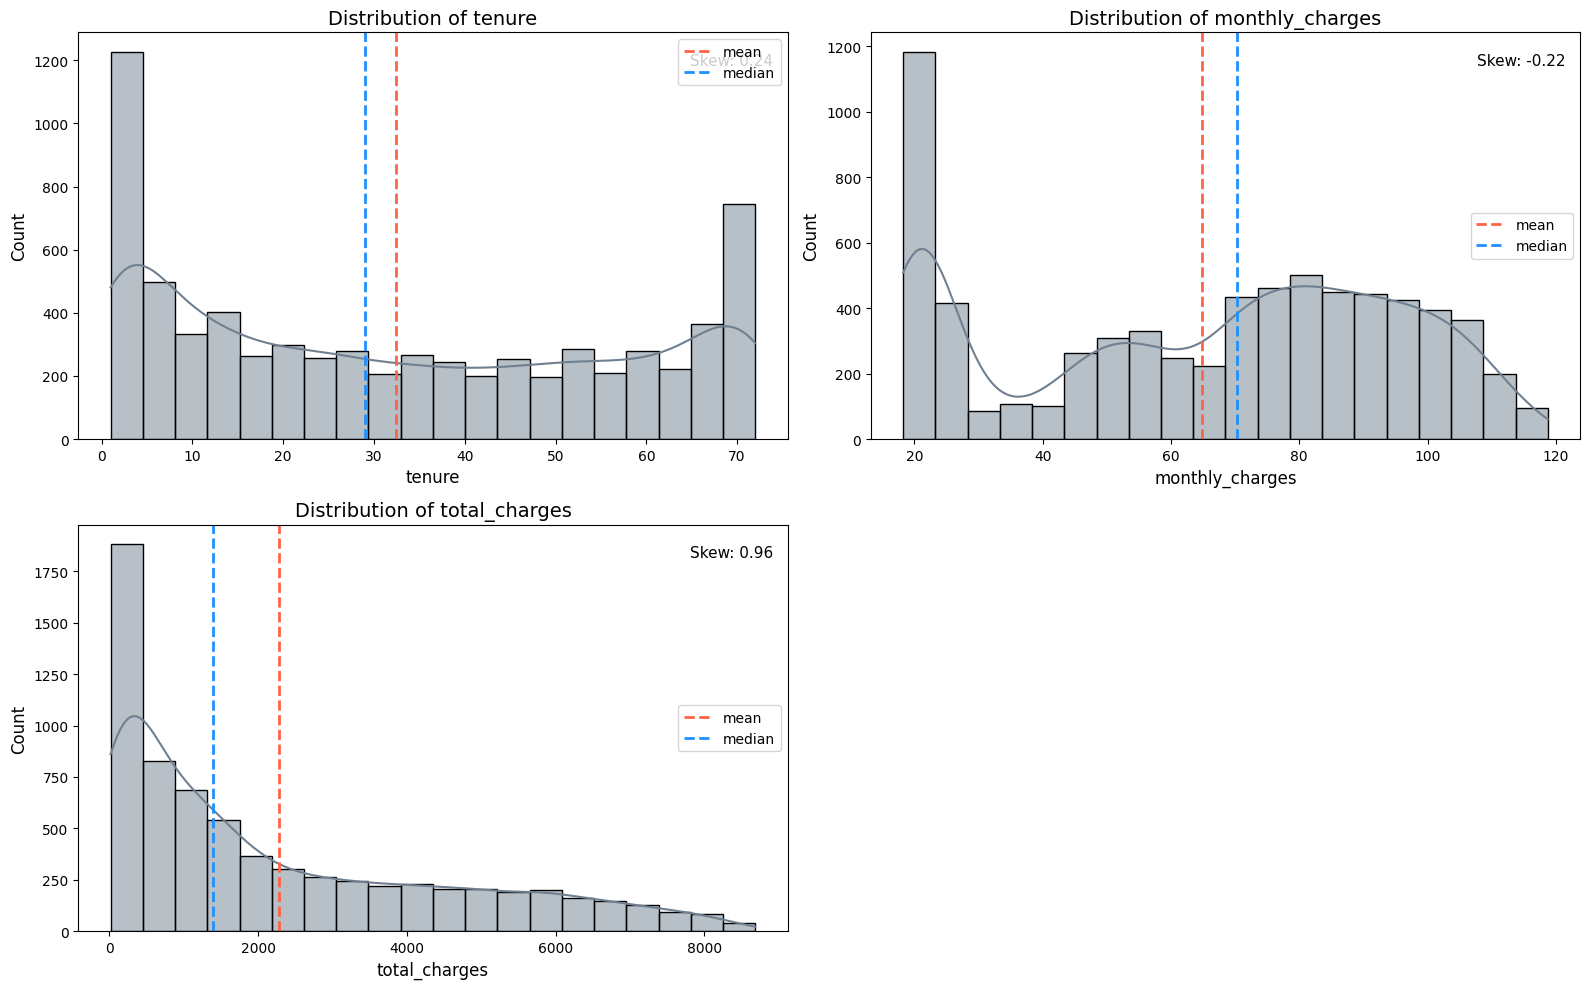

In [21]:
# --- 1) Hist + KDE + líneas media/mediana + skew ---
num_vars = len(numeric_columns)
num_cols = 2
num_rows = int(np.ceil(num_vars / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 5 * num_rows))
axes = np.array(axes).reshape(-1)  # aplanar siempre

for i, col in enumerate(numeric_columns):
    ax = axes[i]

    # Histograma + KDE
    sns.histplot(df[col], bins=20, kde=True, ax=ax, color="slategray", edgecolor="black")

    # Media / Mediana
    mean_val = df[col].mean()
    median_val = df[col].median()
    mean_line = ax.axvline(mean_val, linestyle="--", linewidth=2, color="tomato", label="mean")
    median_line = ax.axvline(median_val, linestyle="--", linewidth=2, color="dodgerblue", label="median")

    # Skewness (asimetría)
    skew_val = df[col].skew()
    ax.text(
        0.98, 0.95,
        f"Skew: {skew_val:.2f}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=11
    )

    # Títulos y ejes
    ax.set_title(f"Distribution of {col}", fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.legend()

    # Prints limpios (si los quieres en consola)
    print(f"{col}: mean={mean_val:.2f} | median={median_val:.2f} | skew={skew_val:.2f}")

# Eliminar ejes sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Tenure**

* Distribución relativamente balanceada con ligera asimetría positiva (skew ≈ 0.24).
* La media (32.4) es ligeramente mayor que la mediana (29), lo que sugiere una leve cola hacia clientes con mayor antigüedad.
* Se observa concentración importante de clientes en los primeros meses, junto con un grupo significativo de clientes de larga permanencia.
* Esto sugiere dos segmentos claros: clientes nuevos y clientes leales.
* Es probable que el churn se concentre en clientes con menor tenure, lo cual se verificará en el análisis posterior vs churn.

**Monthly Charges**

* Distribución ligeramente sesgada a la izquierda (skew ≈ -0.22).
* La mediana (70.35) es mayor que la media (64.8), indicando presencia de clientes con cargos mensuales bajos que reducen el promedio.
* Se observan dos posibles segmentos: planes básicos de bajo costo y planes más completos de mayor costo.
* Esta variable podría ser relevante para segmentar clientes según tipo de servicio y analizar su relación con churn.
* Se evaluará si cargos mensuales más altos están asociados a mayor probabilidad de churn.

**Total Charges**

* Distribución fuertemente sesgada a la derecha (skew ≈ 0.96).
* La media (2283.3) es considerablemente mayor que la mediana (1397.47), indicando una cola larga de clientes con altos cargos acumulados.
* Esta variable está altamente influenciada por el tenure, ya que representa el gasto acumulado del cliente a lo largo del tiempo.
* Es esperable una alta correlación entre total_charges y tenure, por lo que podría aportar menor valor predictivo independiente en modelos de churn.
* Se evaluará su relación con churn y posible necesidad de transformaciones (por ejemplo, log-transform) para modelado.

* Tenure appears to be the strongest structural variable, with a clear separation between early-stage and long-term customers.
* Total charges is heavily right-skewed and likely correlated with tenure, meaning it may not add significant independent predictive power.
* Monthly charges shows slight negative skewness and potential segmentation between basic and premium plans.

Ahora veamos la relación entre las variables numéricas y el target.

/tmp/ipykernel_793582/3580610886.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_793582/3580610886.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_793582/3580610886.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


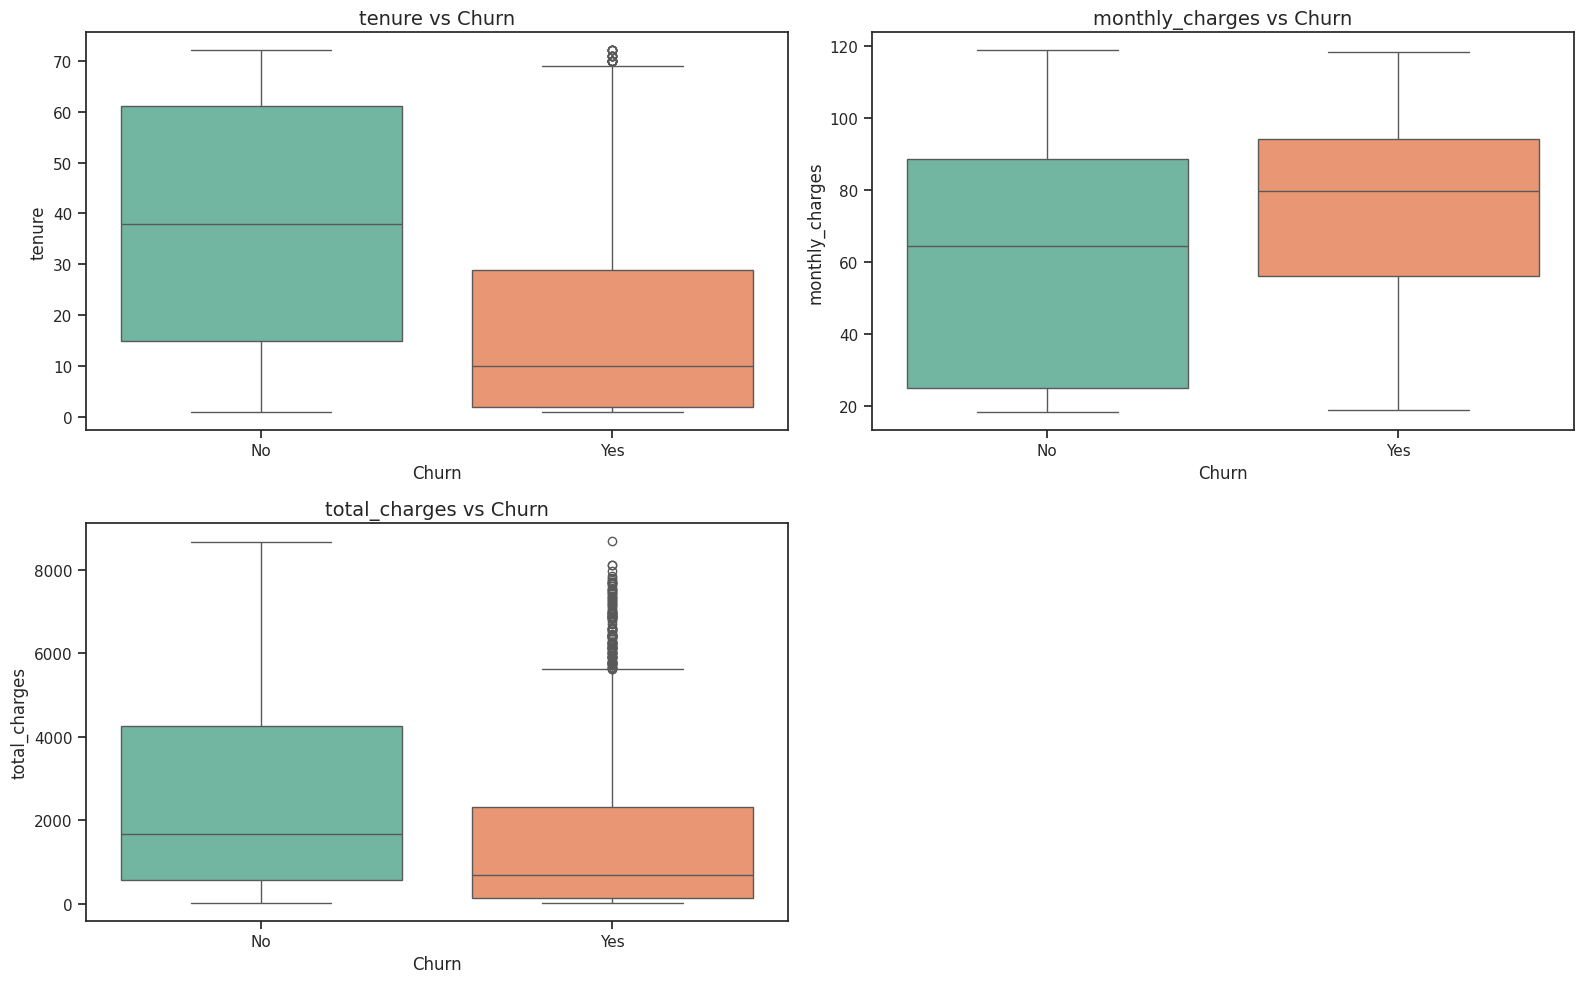

In [22]:
sns.set(style="ticks")

num_vars = numeric_columns
num_cols = 2
num_rows = int(np.ceil(len(num_vars) / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 5 * num_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_vars):
    sns.boxplot(
        x="churn",
        y=col,
        data=df,
        ax=axes[i],
        palette="Set2"
    )
    
    axes[i].set_title(f"{col} vs Churn", fontsize=14)
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)

# Eliminar ejes sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Tenure (Antigüedad)**
- **Patrón**: Los clientes que churnean tienen tenure significativamente menor
- **Interpretación**: El churn se concentra en etapas tempranas del ciclo de vida del cliente
- **Conclusión**: 💡 **Variable más predictiva del dataset**

**Monthly Charges (Cargo Mensual)**
- **Patrón**: Clientes con churn tienen cargos mensuales más altos
- **Interpretación**: Precios elevados están asociados a mayor probabilidad de cancelación
- **Conclusión**: Buena variable predictiva, pero con superposición entre grupos

**Total Charges (Cargo Total Acumulado)**
- **Patrón**: Clientes con churn tienen total charges mucho menores
- **Interpretación**: Confirma que el churn ocurre temprano, antes de acumular gasto elevado
- **Conclusión**: Fuertemente correlacionada con tenure (aporta información redundante)


**Insight Global**

El churn está fuertemente asociado a **clientes nuevos** (bajo tenure y total charges) con **cargos mensuales altos**. Esto indica que el riesgo de cancelación es mayor durante las primeras etapas del ciclo de vida del cliente, especialmente cuando los costos percibidos son elevados.


### 4.3 Categorical Variables

Veamos la frecuencia de los valores de las variables categóricas.

In [23]:
for col in categorical_columns:
    print(df[col].value_counts(normalize=True))
    print("-"*100)


online_backup
No                     0.438993
Yes                    0.344852
No internet service    0.216155
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
paperless_billing
Yes    0.592719
No     0.407281
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
streaming_tv
No                     0.399460
Yes                    0.384386
No internet service    0.216155
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
streaming_movies
No                     0.395478
Yes                    0.388367
No internet service    0.216155
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
phone_service
Yes    0.903299
No     0.096701
Name: proportion, dtype: float64
---

* More than half of customers (55%) are under month-to-month contracts, suggesting high flexibility in the customer base.
* 44% of customers use fiber optic internet, while 21% have no internet service.
* Several service-related variables (online security, backup, streaming, tech support) share the same “No internet service” proportion (≈21.6%), indicating structural dependency with internet_service.
* A large portion of customers do not subscribe to additional services such as online security or tech support.
* Payment methods are relatively evenly distributed, though electronic check is the most common.
* Demographic variables such as gender are balanced and may have limited predictive power.

Antes incluso de ver churn:

Las variables que parecen más prometedoras:

1. contract
2. internet_service
3. tech_support
4. online_security
5. payment_method

Las que parecen menos prometedoras:

* gender
* phone_service



Ahora veamos la relación entre las variables categóricas y el target.

/tmp/ipykernel_793582/3110660755.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_793582/3110660755.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_793582/3110660755.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_793582/3110660755.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_793582/3110660755.py:24: FutureWa

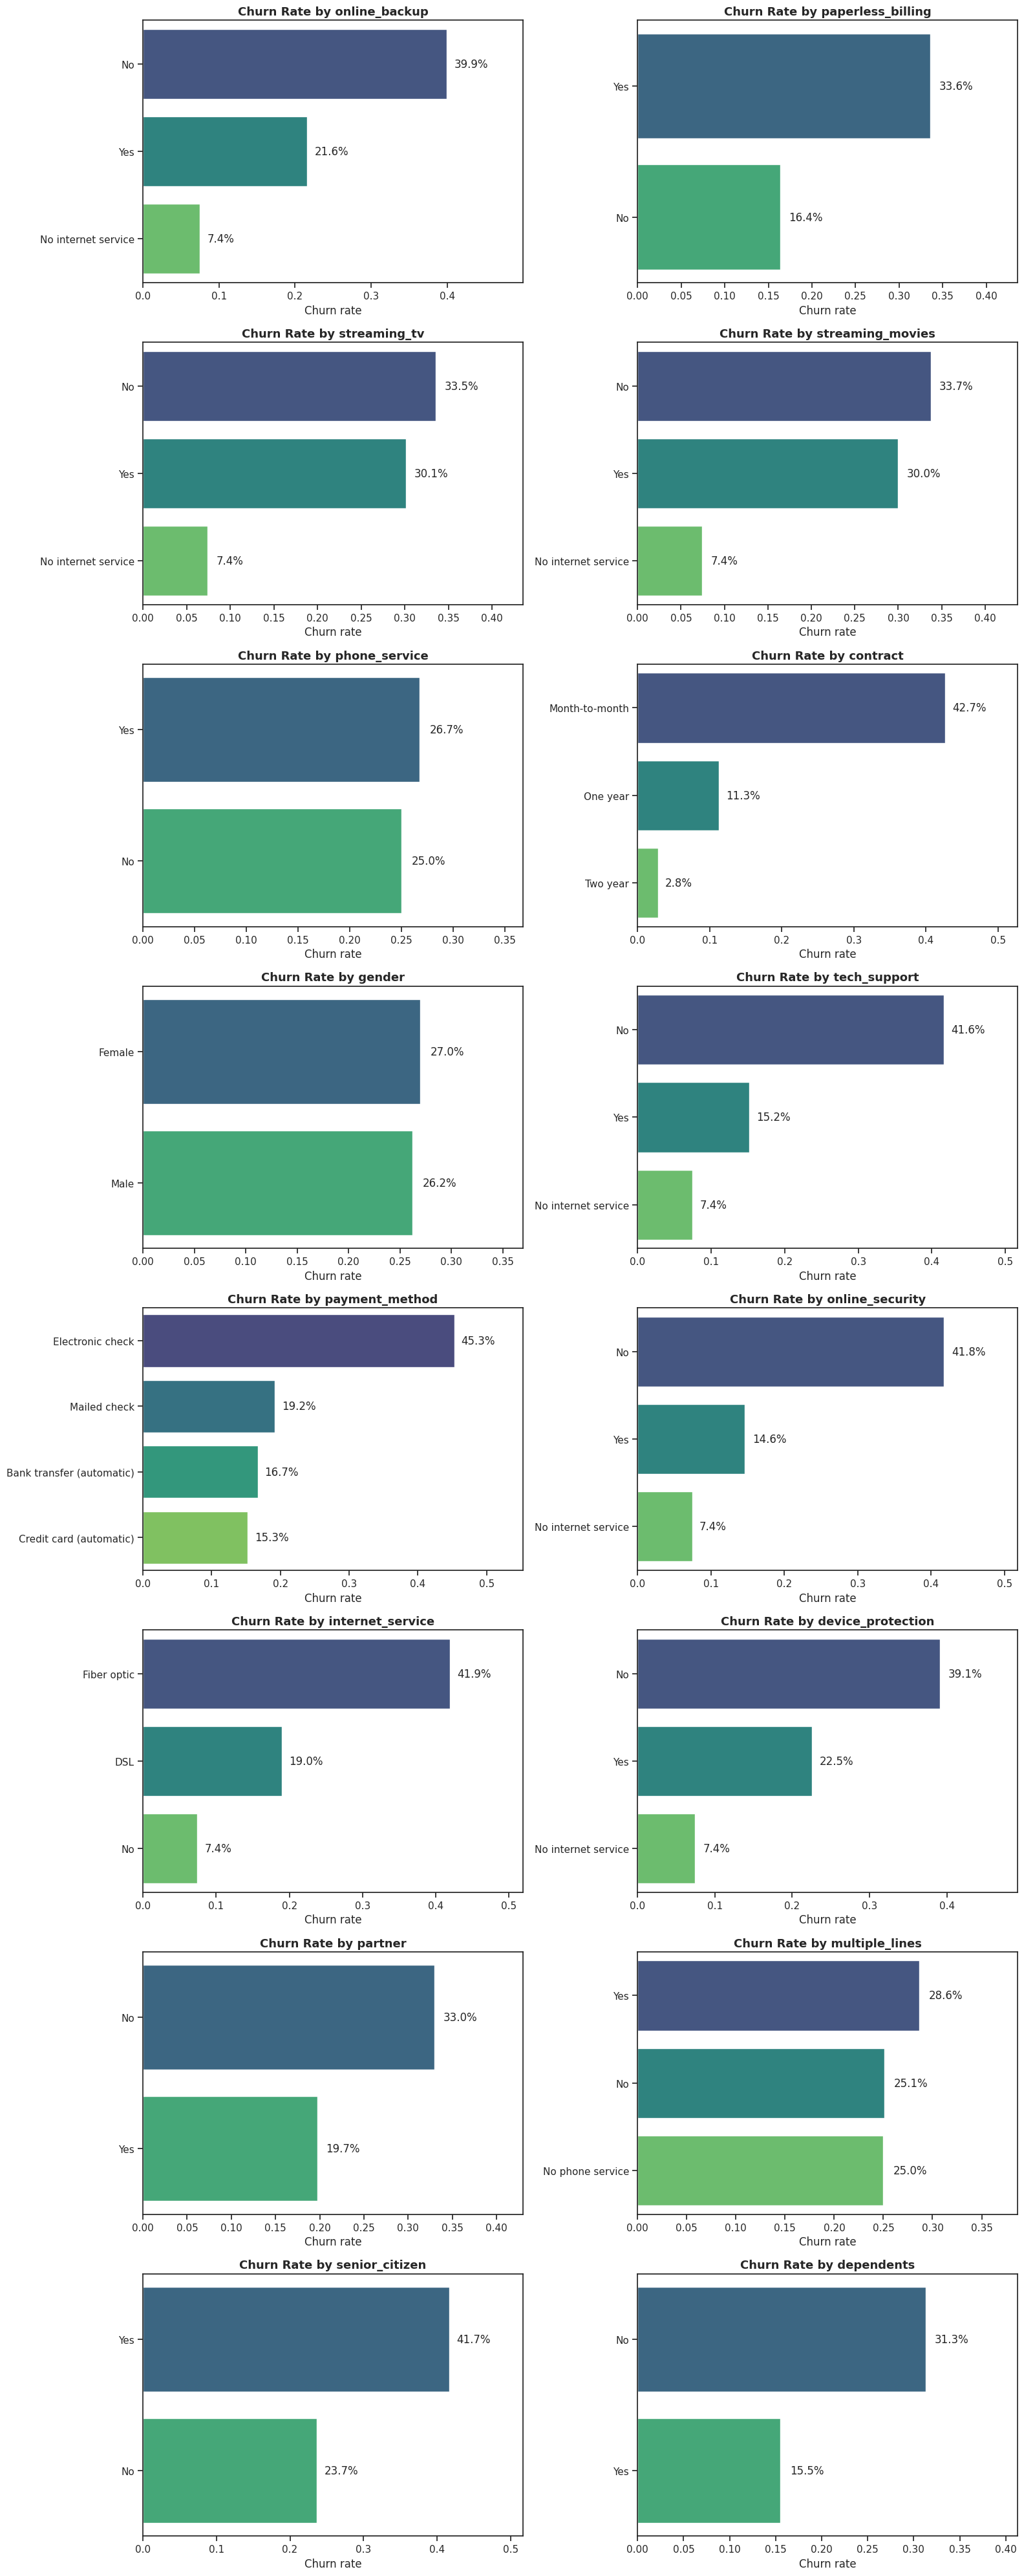

In [24]:
sns.set(style="ticks")

cat_cols = categorical_columns  # tu lista de categóricas
n_cols = 2
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cat_cols):
    
    ax = axes[i]
    
    # calcular churn rate
    churn_rate = (
        df.groupby(col)['churn']
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )
    
    churn_rate = churn_rate["Yes"].sort_values(ascending=False)
    
    sns.barplot(
        x=churn_rate.values,
        y=churn_rate.index,
        ax=ax,
        palette="viridis"
    )
    
    ax.set_title(f"Churn Rate by {col}", fontsize=13, weight="bold")
    ax.set_xlabel("Churn rate")
    ax.set_ylabel("")
    
    # etiquetas %
    for j, v in enumerate(churn_rate.values):
        ax.text(v + 0.01, j, f"{v:.1%}", va="center")
    
    ax.set_xlim(0, churn_rate.max() + 0.1)

# borrar ejes vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Estos son los principales insights que se pueden obtener de las variables categóricas respecto al churn:

* Customers under month-to-month contracts exhibit significantly higher churn rates.
* Payment method, particularly electronic check, is strongly associated with churn.
* Customers without value-added services (tech support, online security, backup) churn at much higher rates.
* Fiber optic customers show higher churn compared to DSL users.
* Demographic variables such as gender show minimal impact.



### 4.4 Tenure Deep Dive

/tmp/ipykernel_793582/1698132476.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_1.groupby("tenure_group")["churn"]
/tmp/ipykernel_793582/1698132476.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


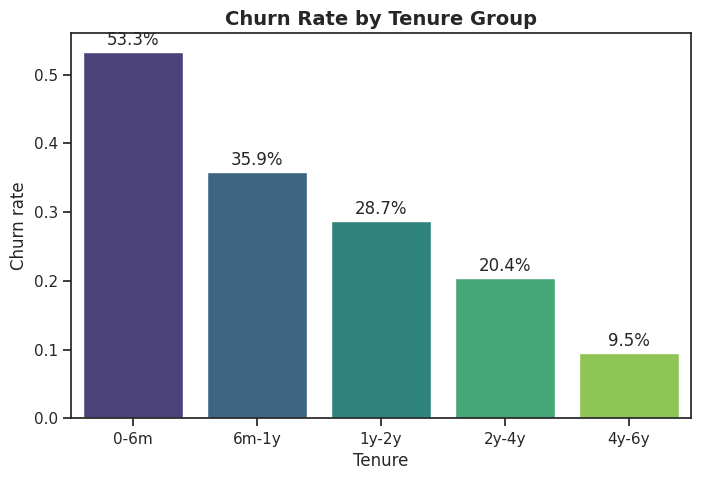

In [25]:
df_1 = df.copy()

df_1["tenure_group"] = pd.cut(
    df_1["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0-6m", "6m-1y", "1y-2y", "2y-4y", "4y-6y"]
)

tenure_churn = (
    df_1.groupby("tenure_group")["churn"]
    .value_counts(normalize=True)
    .unstack()
)

tenure_churn = tenure_churn["Yes"].reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=tenure_churn,
    x="tenure_group",
    y="Yes",
    palette="viridis"
)

plt.title("Churn Rate by Tenure Group", fontsize=14, weight="bold")
plt.ylabel("Churn rate")
plt.xlabel("Tenure")

for i, v in enumerate(tenure_churn["Yes"]):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.show()

/tmp/ipykernel_793582/3703430675.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_1.groupby(["tenure_group","contract"])["churn"]


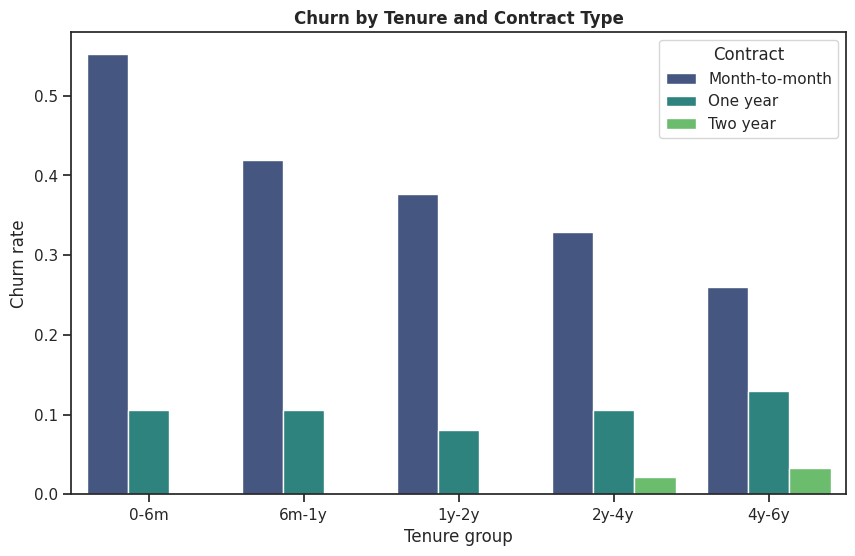

In [26]:
contract_tenure = (
    df_1.groupby(["tenure_group","contract"])["churn"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

contract_tenure = contract_tenure["Yes"].reset_index()

plt.figure(figsize=(10,6))
sns.barplot(
    data=contract_tenure,
    x="tenure_group",
    y="Yes",
    hue="contract",
    palette="viridis"
)

plt.title("Churn by Tenure and Contract Type", weight="bold")
plt.ylabel("Churn rate")
plt.xlabel("Tenure group")
plt.legend(title="Contract")

plt.show()


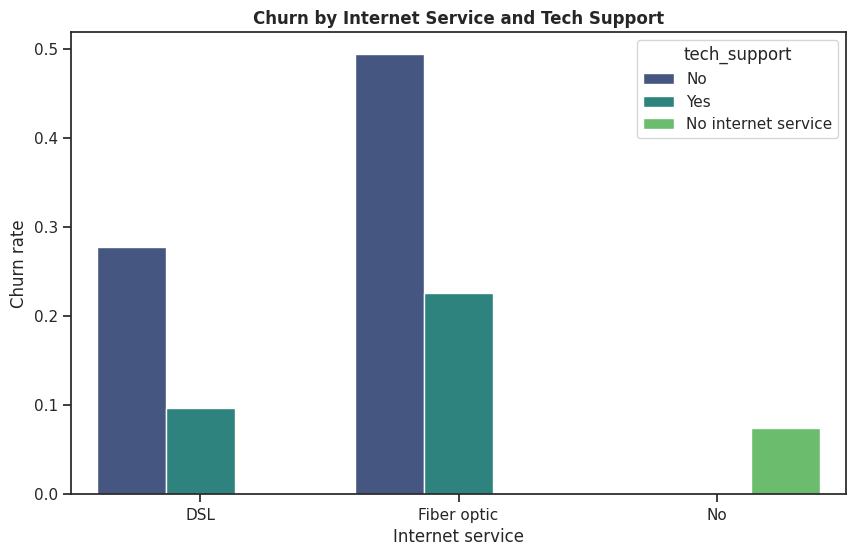

In [27]:
internet_support = (
    df_1.groupby(["internet_service","tech_support"])["churn"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

internet_support = internet_support["Yes"].reset_index()

plt.figure(figsize=(10,6))
sns.barplot(
    data=internet_support,
    x="internet_service",
    y="Yes",
    hue="tech_support",
    palette="viridis"
)

plt.title("Churn by Internet Service and Tech Support", weight="bold")
plt.ylabel("Churn rate")
plt.xlabel("Internet service")
plt.show()


* Churn is highly concentrated in the early stages of the customer lifecycle, particularly within the first year.
* Contract type is the strongest predictor of churn, with month-to-month customers exhibiting significantly higher churn rates.
* Customers using fiber optic services without additional support services present some of the highest churn rates.
* Value-added services such as tech support significantly reduce churn across all customer segments.
* Long-tenure customers under longer contracts demonstrate strong retention and low churn risk.


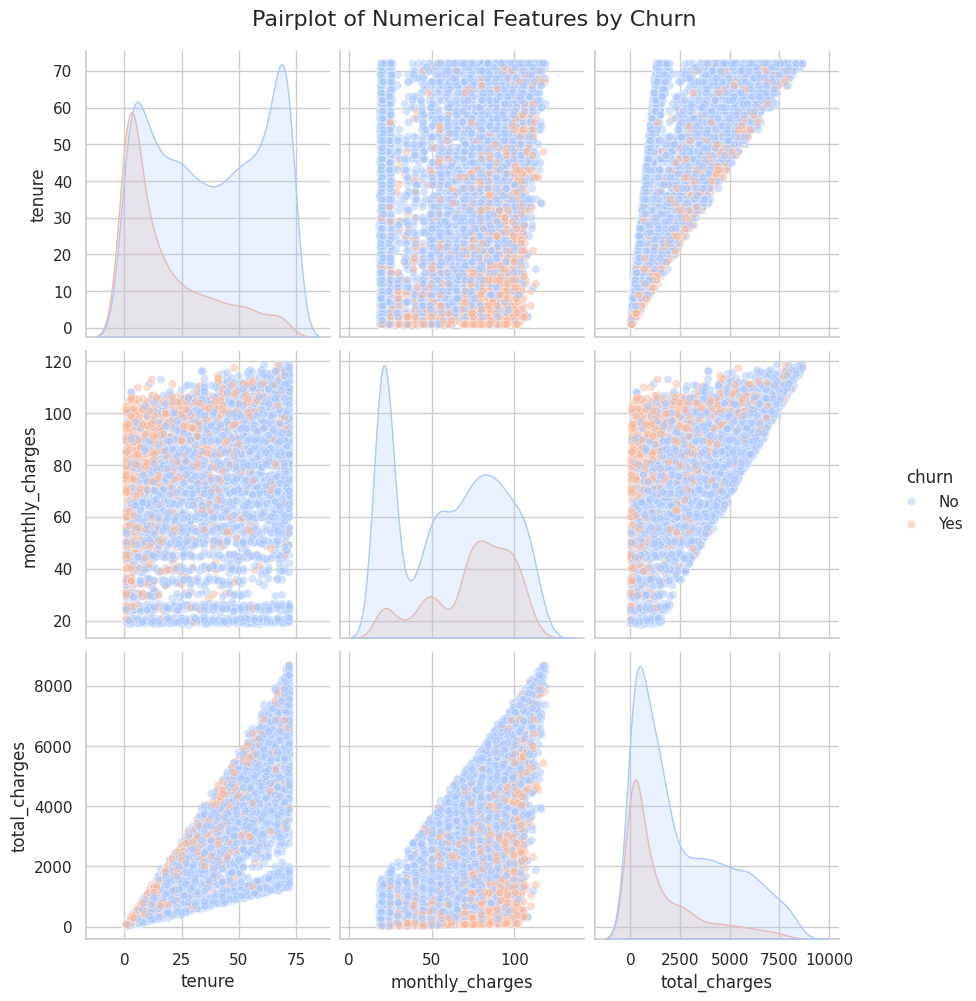

In [28]:
sns.set(style="whitegrid")

cols = ["tenure", "monthly_charges", "total_charges", "churn"]

pair = sns.pairplot(
    df_1[cols],
    hue="churn",
    palette="coolwarm",
    diag_kind="kde",
    plot_kws={"alpha":0.5}
)

pair.fig.set_size_inches(10,10)
pair.fig.suptitle("Pairplot of Numerical Features by Churn", y=1.02, fontsize=16)

plt.show()


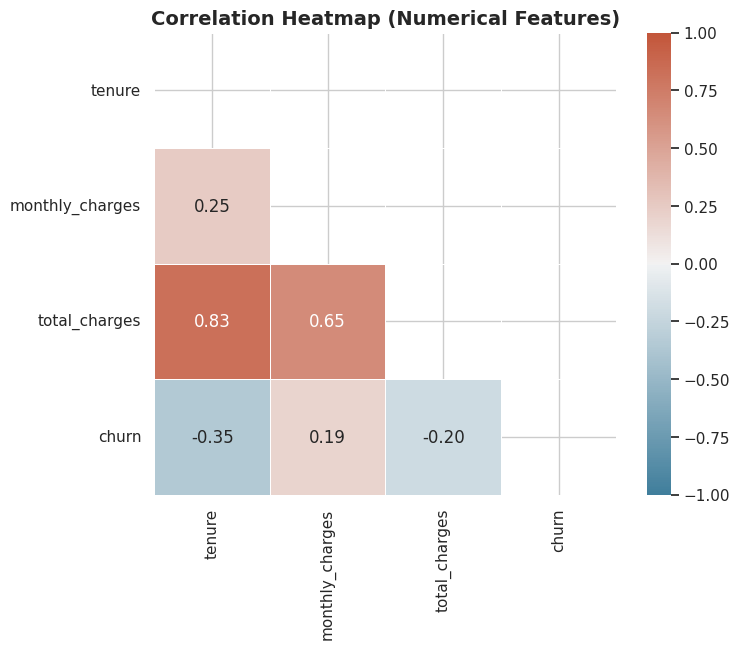

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Copia para no modificar original
df_corr = df.copy()

# Convertir churn a numérico solo para correlación
df_corr["churn"] = df_corr["churn"].map({"Yes":1, "No":0})

corr = df_corr[cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=1,
    vmin=-1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=.5
)

plt.title("Correlation Heatmap (Numerical Features)", fontsize=14, weight="bold")
plt.show()


Pairwise relationships among numerical variables confirm that churn is concentrated among low-tenure customers, with limited separation across other numerical features.


### Conclusion

* Customer churn (~26%) is primarily concentrated in the early stages of the customer lifecycle, with significantly higher churn among customers with low tenure.
* Contract type is the strongest driver of churn: customers under month-to-month contracts show substantially higher churn compared to those with annual or two-year contracts.
* Customers with higher monthly charges and flexible contracts tend to churn more frequently, suggesting pricing sensitivity and lower commitment.
* Value-added services such as tech support, online security, and backup are associated with lower churn, indicating that higher engagement and perceived value improve retention.
* Payment behavior also plays an important role: customers using electronic check exhibit notably higher churn compared to those using automatic payment methods.
* Demographic variables such as gender show minimal impact on churn, while behavioral and service-related variables are more influential.

Churn is mainly driven by contract flexibility, early customer lifecycle, service engagement, and payment behavior. These insights provide a strong foundation for building predictive models and designing targeted retention strategies.

## 5. Feature Engineering

Now that we analyze our dataset and it is clean. We are going to add some features to the dataset to help us to build a better model.

### Numer of total services

As we observed in the EDA, the services are related to the churn. So, we are going to add a feature that counts the number of services that the customer has.

In [31]:
services = [
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies"
]

df["num_services"] = (df[services] == "Yes").sum(axis=1)

### Manual payment vs automatic payment

We are going to identify the customers that have automatic payment methods, which is a good indicator of churn.

In [32]:
df["auto_payment"] = df["payment_method"].isin([
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]).astype(int)


### Intensity of payment vs number of services

Customers who pay a lot but use little → risk. This measure the percived value vs the price.

In [33]:
df["avg_charge_per_service"] = (
    df["monthly_charges"] / (df["num_services"] + 1)
)

Lets review the dataset again with the new features.

In [34]:
# review teh dataset
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,...,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,num_services,auto_payment,avg_charge_per_service
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,0,14.925000
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,2,0,18.983333
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2,0,17.950000
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3,1,10.575000
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,0,70.700000


In [35]:
df.columns

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn',
       'num_services', 'auto_payment', 'avg_charge_per_service'],
      dtype='object')

Finally, we are going to check the correlation between the new features and the target.

In [36]:
df[["tenure", "monthly_charges", "total_charges",
    "num_services", "avg_charge_per_service"]].corr()


,tenure,monthly_charges,total_charges,num_services,avg_charge_per_service
tenure,1.000000,0.246862,0.825880,0.495318,-0.374254
monthly_charges,0.246862,1.000000,0.651065,0.724768,0.110465
total_charges,0.825880,0.651065,1.000000,0.746101,-0.276078
num_services,0.495318,0.724768,0.746101,1.000000,-0.486957
avg_charge_per_service,-0.374254,0.110465,-0.276078,-0.486957,1.000000


### Conclusion

**Nuevas Features Creadas**

Se generaron tres variables derivadas para capturar patrones de comportamiento no evidentes en las variables originales:

- **`num_services`**: Cuenta total de servicios adicionales contratados (0-6)
- **`auto_payment`**: Indica si usa método de pago automático (0/1)
- **`avg_charge_per_service`**: Cargo mensual promedio por servicio contratado

**Correlation Analysis**

`total_charges` confirma alta correlación con `tenure` (0.83). La nueva variable `avg_charge_per_service` muestra correlación negativa con `num_services` (-0.49) y `tenure` (-0.37), capturando el concepto de "valor percibido": clientes que pagan mucho por pocos servicios tienden a irse más rápido. Su baja correlación con `monthly_charges` (0.11) indica que aporta información complementaria útil para el modelo.


## 6. Data Preparation for Modeling

### 5.1 Target Variable Encoding

In [ ]:
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

### 5.2 Feature Selection

In [ ]:
numeric_features = [
    'tenure',
    'monthly_charges',
    'total_charges',
    'num_services',
    'avg_charge_per_service'
]

target_column = ['churn']

categorical_features = list(set(df.columns) - set(numeric_columns) - set(target_column))

NameError: name 'df' is not defined

### 5.3 Train/Test Split

In [ ]:
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

### 5.4 Preprocessing Pipeline

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

El dataset está preparado para modelado: variable objetivo churn convertida a binario (1/0), 5 features numéricas y 17 categóricas definidas, y split estratificado 80/20 que mantiene la proporción de churn (~26%) en ambos conjuntos para evaluación robusta. Configuramos un pipeline de preprocesamiento con StandardScaler para variables numéricas y OneHotEncoder(drop="first") para categóricas, previniendo data leakage y multicolinealidad. Procedemos a comparar múltiples algoritmos para identificar el mejor predictor de churn.


## 6. Modelling

### 6.1 Approach Overview

Para identificar el mejor modelo predictivo de churn, seguiremos una metodología iterativa en 4 etapas:

**Stage 1: Baseline Models** → Elección de modelo base

**Stage 2: Model Selection** → Top 3 modelos evaluados con cross-validation

**Stage 3: Hyperparameter Tuning** → Optimización de los mejores candidatos

**Stage 4: Final Selection** → Decisión basada en performance + interpretabilidad + complejidad

**Métricas de Evaluación:**
- **ROC-AUC**: Capacidad general de discriminación entre clases
- **PR-AUC**: Performance específica en clase minoritaria (churn) - métrica crítica dado el desbalance
- **Precision**: Proporción de predicciones positivas correctas (minimizar falsos positivos)
- **Recall**: Proporción de churners reales capturados (minimizar falsos negativos)
- **F1-Score**: Balance entre precision y recall

**Criterio de selección**: Priorizaremos **PR-AUC** y **Recall** dado el contexto de negocio donde es preferible contactar clientes adicionales (falsos positivos) antes que perder churners reales (falsos negativos).


### 6.2 Baseline Models

Para el modelo base, usaremos el modelo de regresión logística.

In [41]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

In [42]:
logreg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [43]:
y_pred_lg = logreg_pipeline.predict(X_test)
y_proba_lg = logreg_pipeline.predict_proba(X_test)[:,1]

In [44]:
print("Precision:", precision_score(y_test, y_pred_lg))
print("Recall:", recall_score(y_test, y_pred_lg))
print("F1:", f1_score(y_test, y_pred_lg))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lg))

Precision: 0.6443768996960486
Recall: 0.5668449197860963
F1: 0.6031294452347084
ROC AUC: 0.8354993762003614


In [3]:
cm = confusion_matrix(y_test, y_pred_lg)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

NameError: name 'y_test' is not defined

**Results Analysis**

* **Accuracy**: Accuracy tells us how often the model made correct predictions, that is, the proportion of correct predictions out of the total observations. In this case, the model correctly predicted 80% of the cases, meaning that out of every 10 customers, the model correctly predicts 8. However, this does not necessarily mean the model is good, since, as we've seen, about 70% of customers do not churn. This implies that if the model simply always predicted that customers will stay, it could still achieve a high accuracy.
* **Precision**: Precision tells us, out of all the times the model predicted the positive class (that a customer will churn), how often this prediction was correct. In other words, it measures how accurately the model predicts which customers will churn. In our baseline model, the precision was about 64%, which means that only 64% of positive predictions were correct. When the model predicts a customer will churn, there is a 64% chance that the customer will actually churn.
* **Recall**: Recall measures how many of the actual positive cases were found by the model, that is, how many customers who actually churned were detected. The model achieved a recall of 56%, meaning that of the customers who did leave, the model correctly predicted 56% of them.
* **F1**: The F1 score is the harmonic mean of precision and recall. It evaluates the balance between false alarms (false positives) and false negatives, that is, the balance between detecting positives and not making too many mistakes. The baseline model achieved an F1 score of 0.60, which suggests a reasonable balance between detecting positives and not making too many errors.
* **ROC AUC**: ROC AUC is the area under the ROC curve, which measures the model’s ability to distinguish between classes. It reflects how well the model can tell apart customers who will churn and those who will not, regardless of any specific classification threshold. The baseline model had a ROC AUC of approximately 0.83, indicating good discrimination ability. In practical terms, this means the model is able to assign higher probabilities of churn to customers who do leave as compared to those who stay.


The confusion matrix shows that the model correctly identifies 212 churn customers but fails to detect 162 customers who actually churn. This indicates that approximately 43% of churn cases are not captured by the model.

From a business perspective, false negatives represent lost opportunities for retention, as these customers leave without being targeted by intervention strategies. While the model maintains a reasonable balance between precision and recall, improving churn detection (recall) would likely generate higher business value even at the expense of more false positives

Ahora vamos a analizar la curva Precision-Recall.

PR AUC: 0.6232715407951382


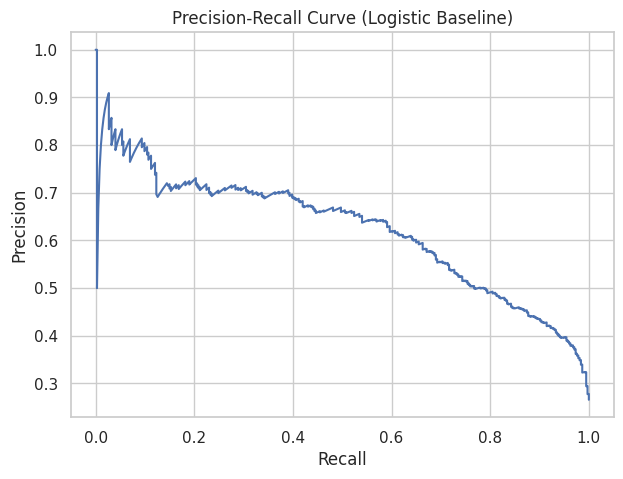

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lg)
pr_auc = average_precision_score(y_test, y_proba_lg)

print("PR AUC:", pr_auc)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic Baseline)")
plt.show()

In [47]:
print("Max recall achievable:", recall.max())
print("Precision when recall high:", precision[:5])

Max recall achievable: 1.0
Precision when recall high: [0.26581379 0.26600284 0.26619217 0.26638177 0.26657163]


El modelo baseline (Logistic Regression) alcanza un PR-AUC ≈ 0.62, lo que indica una capacidad razonable para identificar clientes que harán churn, aunque todavía con margen de mejora. La curva Precision–Recall muestra claramente el trade-off natural del problema: a medida que incrementamos el recall (detectamos más churners), la precisión disminuye. Esto confirma que el modelo sí contiene señal predictiva, pero el threshold por defecto (0.5) no es necesariamente el más adecuado.

Dado que en problemas de churn el costo de no detectar un cliente que se va suele ser alto, resulta necesario ajustar el umbral de decisión en función del objetivo de negocio. Antes de probar modelos más complejos, analizaremos qué recall es alcanzable y qué precisión se sacrifica al mover el threshold.

In [48]:
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lg)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_idx]

print("Best threshold (F1):", best_threshold_f1)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_scores[best_idx])

Best threshold (F1): 0.4260396793905365
Precision: 0.5947242206235012
Recall: 0.6631016042780749
F1: 0.6270543610691135


In [49]:
target_recall = 0.75

idx = np.where(recall >= target_recall)[0][-1]
threshold_recall = thresholds[idx]

print("Threshold for recall≈0.75:", threshold_recall)
print("Precision:", precision[idx])
print("Recall:", recall[idx])

Threshold for recall≈0.75: 0.3072327682119773
Precision: 0.5155963302752293
Recall: 0.7513368983957219


Accuracy: 0.7903340440653873
Precision: 0.5947242206235012
Recall: 0.6631016042780749
F1: 0.6270543615676359
ROC AUC: 0.8354993762003614


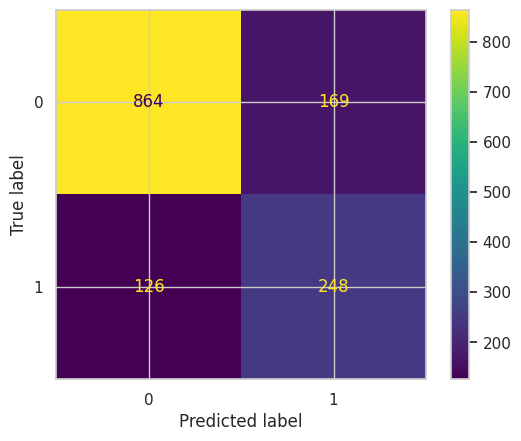

In [50]:
y_pred_opt = (y_proba_lg >= best_threshold_f1).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall:", recall_score(y_test, y_pred_opt))
print("F1:", f1_score(y_test, y_pred_opt))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lg))

cm = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm).plot()

### 📊 Threshold tuning — interpretación

El threshold óptimo según F1 se encuentra en **≈ 0.43**, lo que mejora el equilibrio entre precision y recall respecto al threshold por defecto (0.5). Con este ajuste, el modelo alcanza:

* Precision ≈ 0.59
* Recall ≈ 0.66
* F1 ≈ 0.63

Esto representa una mejora en la capacidad del modelo para detectar clientes que harán churn, aumentando el recall sin sacrificar excesivamente la precisión.

Si priorizamos negocio y buscamos detectar al menos **75% de los churners**, el threshold debe reducirse a ≈ **0.31**, lo que incrementa el recall pero reduce la precisión a ~51%. Esto implica que se capturan más clientes en riesgo, pero con mayor número de falsas alarmas.

En un entorno real, la elección del threshold dependería del costo de retención vs. costo de perder un cliente. Este análisis demuestra que el modelo baseline ya permite ajustar la estrategia de detección sin necesidad de modificar aún el algoritmo.

In [51]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """
    Entrena el pipeline y evalúa en test.
    Devuelve métricas clave + threshold default 0.5 (predict()).
    """
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # proba para ROC/PR (si el modelo tiene predict_proba)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # fallback por si algún modelo expone decision_function
        y_scores = model.decision_function(X_test)
        # escala a [0,1] solo para tener algo comparable (no es calibración real)
        y_proba = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min() + 1e-9)

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }

def run_benchmark(models_dict, X_train, y_train, X_test, y_test):
    rows = []
    for name, model in models_dict.items():
        rows.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))
    df_results = pd.DataFrame(rows).sort_values(["pr_auc", "roc_auc"], ascending=False)
    return df_results

In [52]:

# Logistic
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, n_jobs=-1))
])

# Random Forest
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])

models = {
    "LogReg (baseline)": logreg_pipeline,
    "RandomForest (baseline)": rf_pipeline,
}

# XGBoost
try:
    from xgboost import XGBClassifier
    xgb_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ))
    ])
    models["XGBoost (baseline)"] = xgb_pipeline
except Exception as e:
    print("XGBoost not available:", e)

# LightGBM
try:
    from lightgbm import LGBMClassifier
    lgbm_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=800,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            n_jobs=-1
        ))
    ])
    models["LightGBM (baseline)"] = lgbm_pipeline
except Exception as e:
    print("LightGBM not available:", e)

# CatBoost (ojo: maneja categóricas nativas, pero aquí lo usamos con OHE para comparar apples-to-apples)
try:
    from catboost import CatBoostClassifier
    cat_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", CatBoostClassifier(
            iterations=800,
            learning_rate=0.05,
            depth=6,
            random_state=42,
            verbose=0
        ))
    ])
    models["CatBoost (baseline)"] = cat_pipeline
except Exception as e:
    print("CatBoost not available:", e)

In [53]:
results_stage2 = run_benchmark(models, X_train, y_train, X_test, y_test)
results_stage2

/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 902
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151


/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,XGBoost (baseline),0.777541,0.593846,0.516043,0.552217,0.826861,0.637019
0,LogReg (baseline),0.801706,0.644377,0.566845,0.603129,0.835499,0.623272
4,CatBoost (baseline),0.778962,0.596330,0.521390,0.556348,0.818186,0.613407
1,RandomForest (baseline),0.781095,0.607843,0.497326,0.547059,0.816247,0.598591
3,LightGBM (baseline),0.769723,0.572254,0.529412,0.550000,0.810783,0.593712


In [54]:
top_models = results_stage2["model"].head(3).tolist()
top_models

['XGBoost (baseline)', 'LogReg (baseline)', 'CatBoost (baseline)']

Now let's take the top 3 models and do cross validation and hyperparameter tuning.

In [55]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "pr_auc": "average_precision"
}

def run_cv(model_name, pipeline):
    
    scores = cross_validate(
        pipeline,
        X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    return {
        "model": model_name,
        "roc_auc": scores["test_roc_auc"].mean(),
        "pr_auc": scores["test_pr_auc"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
    }

In [56]:
cv_results = []

cv_results.append(run_cv("Logistic", logreg_pipeline))
cv_results.append(run_cv("XGBoost", xgb_pipeline))
cv_results.append(run_cv("CatBoost", cat_pipeline))

cv_results_df = pd.DataFrame(cv_results).sort_values("pr_auc", ascending=False)
cv_results_df

/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: F

,model,roc_auc,pr_auc,precision,recall,f1
0,Logistic,0.846103,0.659302,0.659369,0.547157,0.597921
1,XGBoost,0.840399,0.650613,0.635776,0.513712,0.567839
2,CatBoost,0.834157,0.638533,0.638733,0.517726,0.571283


As we can observe, the Logistic Regression has the best results in echa metric, followed by the XGBoost. Lets tune this two models and see if we can improve the results.

In [57]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

In [58]:
param_distributions = [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": loguniform(1e-3, 1e2),
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__solver": ["saga"],
        "model__penalty": ["l1", "l2"],
        "model__C": loguniform(1e-3, 1e2),
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": loguniform(1e-3, 1e2),
        "model__class_weight": [None, "balanced"]
    }
]

In [59]:
search_logreg = RandomizedSearchCV(
    estimator=logreg_base,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="average_precision",   # PR-AUC
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

search_logreg.fit(X_train, y_train)

best_logreg = search_logreg.best_estimator_
print("Best params:", search_logreg.best_params_)
print("Best CV PR-AUC:", search_logreg.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penal

Best params: {'model__C': np.float64(0.14445251022763064), 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV PR-AUC: 0.6613982858806128


/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Test Accuracy: 0.8024164889836531
Test Precision: 0.6481481481481481
Test Recall: 0.5614973262032086
Test F1: 0.6017191977077364
Test ROC-AUC: 0.8362111807672994
Test PR-AUC: 0.6283836797443239


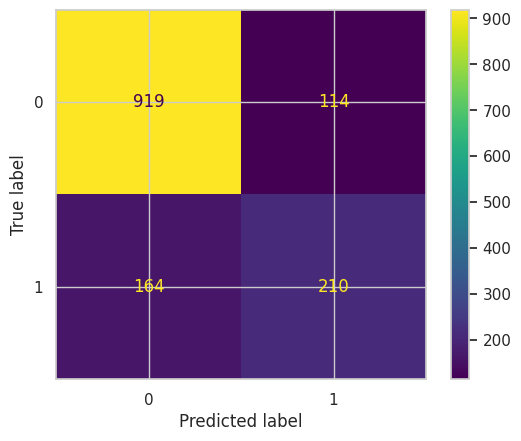

In [60]:
y_pred = best_logreg.predict(X_test)
y_proba = best_logreg.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [61]:
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

cv_best = cross_validate(
    best_logreg,
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

summary = {k: (np.mean(v), np.std(v)) for k, v in cv_best.items() if k.startswith("test_")}
summary

/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/ubuntu/ricardo/telco_customer_churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead

{'test_roc_auc': (np.float64(0.8456874002931482),
  np.float64(0.006003695569760096)),
 'test_pr_auc': (np.float64(0.6613982858806128),
  np.float64(0.012993024374663615)),
 'test_precision': (np.float64(0.6545471054377494),
  np.float64(0.02340813689576044)),
 'test_recall': (np.float64(0.5357859531772575),
  np.float64(0.020982457714191452)),
 'test_f1': (np.float64(0.5891417670490398), np.float64(0.020741987791624995))}

In [62]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "random_state": 42,
        "eval_metric": "logloss",
        "n_jobs": -1
    }

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(**params))
    ])

    scores = cross_val_score(
        model,
        X_train, y_train,
        cv=cv,
        scoring="average_precision",
        n_jobs=-1
    )

    return scores.mean()

In [63]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print("  Value (PR-AUC):", study.best_trial.value)
print("  Params:", study.best_trial.params)

[I 2026-02-26 22:17:00,215] A new study created in memory with name: no-name-69cd2316-55b7-4675-a1c5-e9d7c2aba29f
[I 2026-02-26 22:17:00,749] Trial 0 finished with value: 0.6687087668545313 and parameters: {'n_estimators': 1048, 'max_depth': 7, 'learning_rate': 0.035689483070357915, 'subsample': 0.811971255819729, 'colsample_bytree': 0.6046260924928576, 'min_child_weight': 1, 'gamma': 4.856742550628007, 'reg_lambda': 4.262352502182678}. Best is trial 0 with value: 0.6687087668545313.
[I 2026-02-26 22:17:01,031] Trial 1 finished with value: 0.6625132104279876 and parameters: {'n_estimators': 476, 'max_depth': 5, 'learning_rate': 0.15190116667501635, 'subsample': 0.8031071644279166, 'colsample_bytree': 0.6469993513561852, 'min_child_weight': 6, 'gamma': 4.032786858067099, 'reg_lambda': 0.0010162969129605653}. Best is trial 0 with value: 0.6687087668545313.
[I 2026-02-26 22:17:01,261] Trial 2 finished with value: 0.6638037419459282 and parameters: {'n_estimators': 296, 'max_depth': 7, 'le

Best trial:
  Value (PR-AUC): 0.6690240567803244
  Params: {'n_estimators': 1198, 'max_depth': 6, 'learning_rate': 0.04264359029154587, 'subsample': 0.8035765481941507, 'colsample_bytree': 0.8475068974250288, 'min_child_weight': 2, 'gamma': 3.3934426323683007, 'reg_lambda': 1.829913117945467}


In [64]:
best_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        **study.best_trial.params,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

best_xgb.fit(X_train, y_train)

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:,1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("Test PR-AUC:", average_precision_score(y_test, y_proba_xgb))

Test ROC-AUC: 0.8403732961987049
Test PR-AUC: 0.6543489647338441


XGBoost mejora ligeramente el poder predictivo, pero la ganancia es marginal frente a Logistic Regression, que ofrece mayor interpretabilidad, simplicidad de despliegue y estabilidad. En un entorno productivo, Logistic sería probablemente el modelo elegido.

In [65]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# usa tu modelo final:
final_model = best_logreg  # Logistic tuned

y_proba_final = final_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_final)
pr_auc = average_precision_score(y_test, y_proba_final)

print("Test PR-AUC:", pr_auc)

Test PR-AUC: 0.6283836797443239


In [66]:
import numpy as np

def threshold_for_recall(precision, recall, thresholds, target_recall=0.75):
    # recall tiene length = thresholds+1 → usamos índices compatibles
    idx = np.where(recall[:-1] >= target_recall)[0]
    if len(idx) == 0:
        return None
    # elegimos el threshold más alto que todavía cumple el recall (reduce FP)
    i = idx[-1]
    return thresholds[i], precision[i], recall[i]

thr_75, p_75, r_75 = threshold_for_recall(precision, recall, thresholds, target_recall=0.75)
print("Threshold for recall>=0.75:", thr_75)
print("Precision:", p_75, "Recall:", r_75)

Threshold for recall>=0.75: 0.30827632139784694
Precision: 0.5194085027726433 Recall: 0.7513368983957219


In [67]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

def eval_at_threshold(y_true, y_proba, thr):
    y_pred = (y_proba >= thr).astype(int)
    return {
        "threshold": thr,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "tn_fp_fn_tp": confusion_matrix(y_true, y_pred).ravel()
    }

# threshold F1
f1_scores = 2*(precision*recall)/(precision+recall+1e-9)
best_i = np.argmax(f1_scores[:-1])  # compatibilidad
thr_f1 = thresholds[best_i]

results_thr = []
results_thr.append(eval_at_threshold(y_test, y_proba_final, 0.5))
results_thr.append(eval_at_threshold(y_test, y_proba_final, thr_f1))
results_thr.append(eval_at_threshold(y_test, y_proba_final, thr_75))

pd.DataFrame(results_thr)

,threshold,accuracy,precision,recall,f1,tn_fp_fn_tp
0,0.500000,0.802416,0.648148,0.561497,0.601719,"[919, 114, 164, 210]"
1,0.402753,0.788913,0.588915,0.681818,0.631970,"[855, 178, 119, 255]"
2,0.308276,0.749112,0.519409,0.751337,0.614208,"[773, 260, 93, 281]"


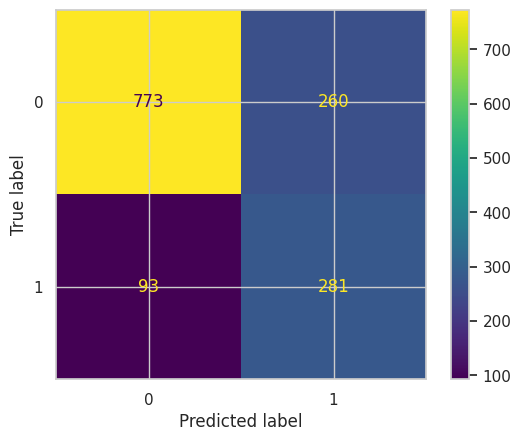

In [68]:
thr_final = thr_75  # o thr_f1, según decisión
y_pred_final = (y_proba_final >= thr_final).astype(int)

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm).plot()

In [69]:
import pandas as pd
import numpy as np

# Extraer nombres de features post-OHE
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
coefs = final_model.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

coef_df.head(15)

,feature,coef,abs_coef
27,cat__contract_Two year,-1.267379,1.267379
9,cat__phone_service_Yes,-1.122613,1.122613
0,num__tenure,-1.065889,1.065889
1,num__monthly_charges,0.846192,0.846192
26,cat__contract_One year,-0.704892,0.704892
15,cat__online_security_Yes,-0.488682,0.488682
21,cat__tech_support_Yes,-0.457500,0.457500
2,num__total_charges,0.321723,0.321723
30,cat__payment_method_Electronic check,0.282529,0.282529
28,cat__paperless_billing_Yes,0.250129,0.250129


Se compararon modelos lineales y boosting, incluyendo validación cruzada y tuning. Aunque XGBoost tuned obtuvo el mejor PR-AUC promedio en CV, la ganancia frente a Logistic tuned fue marginal y no se reflejó en una mejora clara en test. Por tradeoff entre performance, interpretabilidad y facilidad de despliegue, se seleccionó Logistic tuned como modelo final y XGBoost tuned como challenger. Finalmente, se ajustó el threshold para alinear el modelo a un objetivo operativo (p.ej., recall ≥ 0.75), mostrando explícitamente el impacto en FN/FP y los principales drivers de churn mediante coeficientes del modelo.

## 🔵 Conclusión profesional final del modelo (modo senior — listo para notebook)

El modelo final seleccionado fue **Logistic Regression tuneado**, ya que ofreció el mejor balance entre performance, estabilidad e interpretabilidad. Aunque modelos más complejos como XGBoost lograron mejoras marginales en validación cruzada, estas no se tradujeron en un uplift significativo en test y añaden mayor complejidad operativa. Por ello, Logistic se eligió como modelo productivo y XGBoost como challenger.

El análisis de thresholds mostró que el valor estándar de 0.5 no es óptimo para un contexto de churn. Ajustando el threshold a **0.31** se logró capturar aproximadamente **75% de los clientes que realmente churnan**, aumentando significativamente el recall (0.75 vs 0.56 baseline) a costa de una mayor tasa de falsos positivos. Este tradeoff es consistente con escenarios reales de retención, donde suele ser preferible contactar clientes adicionales antes que perder churners reales.

A nivel de drivers de churn, los principales factores asociados a menor churn fueron **contratos largos (one-year/two-year), mayor tenure, presencia de phone service, online security y tech support**, mientras que el churn aumenta con **monthly charges altos, electronic check como método de pago y paperless billing**. Estos insights permiten diseñar estrategias de retención enfocadas en migrar clientes a contratos largos, autopagos y bundles de servicios de soporte.

En conjunto, el modelo desarrollado no solo logra una buena capacidad predictiva (ROC-AUC ≈ 0.84, PR-AUC ≈ 0.63), sino que también proporciona interpretabilidad accionable y un threshold optimizado para toma de decisiones reales de negocio.


## Random Forest

In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
rf_pipeline.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm)
disp.plot()

Now we'll compar the model with the baseline model results.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def eval_model(name, y_true, y_pred, y_proba):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

results = []
results.append(eval_model("LogReg (baseline)", y_test, y_pred_lg, y_proba_lg))
results.append(eval_model("RandomForest (baseline)", y_test, y_pred_rf, y_proba_rf))

pd.DataFrame(results).sort_values("roc_auc", ascending=False)

### 

As we can observe, the Random Forest do not perform better than the Logistic Regression in all metrics. Now let's see if using cross validation and hyperparameter tuning we can improve the model.

### Cross Validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_scores_rf = cross_validate(
    rf_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

pd.DataFrame(cv_scores_rf).mean()

The metrics results improve, but not significantly. It's not better than the baseline model yet.